In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [7]:
rfm = pd.read_csv(r'C:\Users\Ben Ten\OneDrive\Desktop\Projects\Final\Marketing\data\rfm_scores.csv')
customers = pd.read_csv(r'C:\Users\Ben Ten\OneDrive\Desktop\Projects\Final\Marketing\data\clean data\clean_customers.csv')

In [9]:
# Features for clustering

features = rfm[['recency', 'frequency', 'monetary']].copy()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [17]:
features_scaled.mean(axis=0)

array([ 3.91958702e-17, -7.95676166e-17,  1.56783481e-17])

In [18]:
features_scaled.std(axis=0)

array([1., 1., 1.])

In [19]:
# Elbow method to find optimal K

inertia = []
sil_scores = []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(features_scaled, km.labels_))

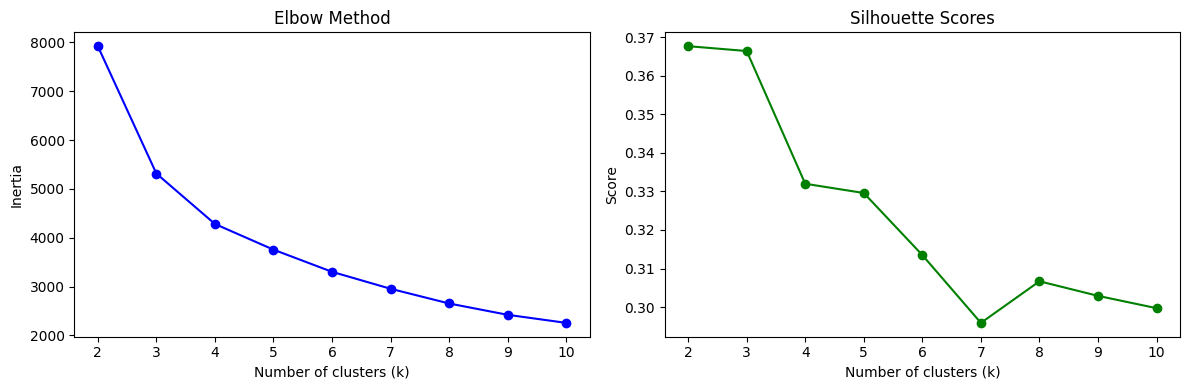

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_RANGE, inertia, marker='o', color='blue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_RANGE, sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
# plt.savefig('kmeans_elbow_silhouette.png', dpi=150)
plt.show()

In [22]:
OPTIMAL_K = 5

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(features_scaled)

In [23]:
rfm.head()

,customer_id,last_order_date,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,rfm_segment,cluster
0,1002,2022-12-06,2,614.95,757,1,2,3,6,Hibernating,2
1,1003,2022-08-25,1,475.38,860,1,1,2,4,Lost,2
2,1004,2024-07-06,2,1067.46,179,4,2,4,10,New Customers,1
3,1005,2024-05-29,3,962.47,217,3,3,4,10,Loyal Customers,3
4,1007,2024-03-01,2,771.54,306,3,2,3,8,Potential Loyalists,1


In [25]:
# Cluster Profiles:

profile = rfm.groupby('cluster').agg(
    n_customers = ('customer_id', 'count'),
    avg_recency = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary = ('monetary', 'mean'),
    avg_rfm_score = ('RFM_score', 'mean')
).round(1).reset_index()

In [26]:
profile

,cluster,n_customers,avg_recency,avg_frequency,avg_monetary,avg_rfm_score
0,0,524,187.7,5.0,2306.5,13.5
1,1,1198,214.5,1.6,442.2,7.5
2,2,883,779.3,1.3,369.1,4.5
3,3,1229,144.7,3.6,1031.2,11.9
4,4,698,513.2,2.7,1021.2,8.8


In [27]:
# Assigning Business Labels based on Profiles:

cluster_labels = {
    profile.sort_values('avg_rfm_score', ascending=False).iloc[0]['cluster']: 'High Value',
    profile.sort_values('avg_rfm_score', ascending=False).iloc[1]['cluster']: 'Loyal',
    profile.sort_values('avg_rfm_score', ascending=False).iloc[2]['cluster']: 'Potential',
    profile.sort_values('avg_rfm_score', ascending=False).iloc[3]['cluster']: 'At-Risk',
    profile.sort_values('avg_rfm_score', ascending=False).iloc[4]['cluster']: 'Lost'
}

In [28]:
cluster_labels

{np.float64(0.0): 'High Value',
 np.float64(3.0): 'Loyal',
 np.float64(4.0): 'Potential',
 np.float64(1.0): 'At-Risk',
 np.float64(2.0): 'Lost'}

In [29]:
rfm['segment_label'] = rfm['cluster'].map(cluster_labels)

In [31]:
rfm.head()

,customer_id,last_order_date,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,rfm_segment,cluster,segment_label
0,1002,2022-12-06,2,614.95,757,1,2,3,6,Hibernating,2,Lost
1,1003,2022-08-25,1,475.38,860,1,1,2,4,Lost,2,Lost
2,1004,2024-07-06,2,1067.46,179,4,2,4,10,New Customers,1,At-Risk
3,1005,2024-05-29,3,962.47,217,3,3,4,10,Loyal Customers,3,Loyal
4,1007,2024-03-01,2,771.54,306,3,2,3,8,Potential Loyalists,1,At-Risk


In [35]:
# Merge Segment back to Customers:

customer_segmented = customers.merge(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'RFM_score', 'rfm_segment', 'cluster', 'segment_label']], on='customer_id', how='left')

In [36]:
customer_segmented.head()

,customer_id,name,email,city,signup_channel,signup_date,age,gender,recency,frequency,monetary,RFM_score,rfm_segment,cluster,segment_label
0,1001,customer_0,customer0.gmail.com,Delhi,Organic,2023-05-07,52,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1002,customer_1,customer1.gmail.com,Delhi,SMS,2024-06-03,36,F,757.0,2.0,614.95,6.0,Hibernating,2.0,Lost
2,1003,customer_2,customer2.gmail.com,Bengaluru,SMS,2022-02-25,48,M,860.0,1.0,475.38,4.0,Lost,2.0,Lost
3,1004,customer_3,customer3.gmail.com,Chennai,SMS,2023-05-31,37,F,179.0,2.0,1067.46,10.0,New Customers,1.0,At-Risk
4,1005,customer_4,customer4.gmail.com,Mumbai,Google Search,2022-01-05,38,M,217.0,3.0,962.47,10.0,Loyal Customers,3.0,Loyal


In [37]:
# Handling Null Values in Segmentation:

customer_segmented['segment_label'] = customer_segmented['segment_label'].fillna('No Purchase')

In [38]:
customer_segmented.head()

,customer_id,name,email,city,signup_channel,signup_date,age,gender,recency,frequency,monetary,RFM_score,rfm_segment,cluster,segment_label
0,1001,customer_0,customer0.gmail.com,Delhi,Organic,2023-05-07,52,M,NaN,NaN,NaN,NaN,NaN,NaN,No Purchase
1,1002,customer_1,customer1.gmail.com,Delhi,SMS,2024-06-03,36,F,757.0,2.0,614.95,6.0,Hibernating,2.0,Lost
2,1003,customer_2,customer2.gmail.com,Bengaluru,SMS,2022-02-25,48,M,860.0,1.0,475.38,4.0,Lost,2.0,Lost
3,1004,customer_3,customer3.gmail.com,Chennai,SMS,2023-05-31,37,F,179.0,2.0,1067.46,10.0,New Customers,1.0,At-Risk
4,1005,customer_4,customer4.gmail.com,Mumbai,Google Search,2022-01-05,38,M,217.0,3.0,962.47,10.0,Loyal Customers,3.0,Loyal


In [39]:
customer_segmented['segment_label'].value_counts()

segment_label
Loyal          1229
At-Risk        1198
Lost            883
Potential       698
High Value      524
No Purchase     468
Name: count, dtype: int64

In [ ]:
'''
customer_segmented.to_csv('customers_segmented.csv', index=False)
rfm.to_csv('rfm_clustered.csv', index=False)
'''